# <h1 align="center"> Machine Learnign Template </h1> </center>

<p style="margin-bottom:1cm;"></p>

# One hot encoding did not help, deleting it and trying to group things to see what helps.

## 1. Load Dependencies

In [474]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading Dataset


In [683]:
df = pd.read_csv("telecom_users.csv").drop(columns=["Unnamed: 0", "customerID"])
print(df.shape)
df.head()

(5986, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


# Churn = yes -> bad
# Churn = no -> good

## 3. Data Preparation and check (shape, info for the column types, checking for missing values)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5986 non-null   str    
 1   SeniorCitizen     5986 non-null   int64  
 2   Partner           5986 non-null   str    
 3   Dependents        5986 non-null   str    
 4   tenure            5986 non-null   int64  
 5   PhoneService      5986 non-null   str    
 6   MultipleLines     5986 non-null   str    
 7   InternetService   5986 non-null   str    
 8   OnlineSecurity    5986 non-null   str    
 9   OnlineBackup      5986 non-null   str    
 10  DeviceProtection  5986 non-null   str    
 11  TechSupport       5986 non-null   str    
 12  StreamingTV       5986 non-null   str    
 13  StreamingMovies   5986 non-null   str    
 14  Contract          5986 non-null   str    
 15  PaperlessBilling  5986 non-null   str    
 16  PaymentMethod     5986 non-null   str    
 17  Monthl

In [684]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5986 non-null   str    
 1   SeniorCitizen     5986 non-null   int64  
 2   Partner           5986 non-null   str    
 3   Dependents        5986 non-null   str    
 4   tenure            5986 non-null   int64  
 5   PhoneService      5986 non-null   str    
 6   MultipleLines     5986 non-null   str    
 7   InternetService   5986 non-null   str    
 8   OnlineSecurity    5986 non-null   str    
 9   OnlineBackup      5986 non-null   str    
 10  DeviceProtection  5986 non-null   str    
 11  TechSupport       5986 non-null   str    
 12  StreamingTV       5986 non-null   str    
 13  StreamingMovies   5986 non-null   str    
 14  Contract          5986 non-null   str    
 15  PaperlessBilling  5986 non-null   str    
 16  PaymentMethod     5986 non-null   str    
 17  Monthl

In [16]:
df.isna().sum() #same as isnull, but this is the newer and preferred format. 

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        10
Churn                0
dtype: int64

In [564]:
df[df["TotalCharges"].isna()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
356,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No
634,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
2771,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
3086,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
3255,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
4326,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
5375,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5382,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5695,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
5951,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No


In [685]:
cat_features = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numc_features = df.select_dtypes(include=['int', 'float']).columns.tolist()


C:\Users\danik\AppData\Local\Temp\ipykernel_29200\2563155406.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Churn", fontsize=8)


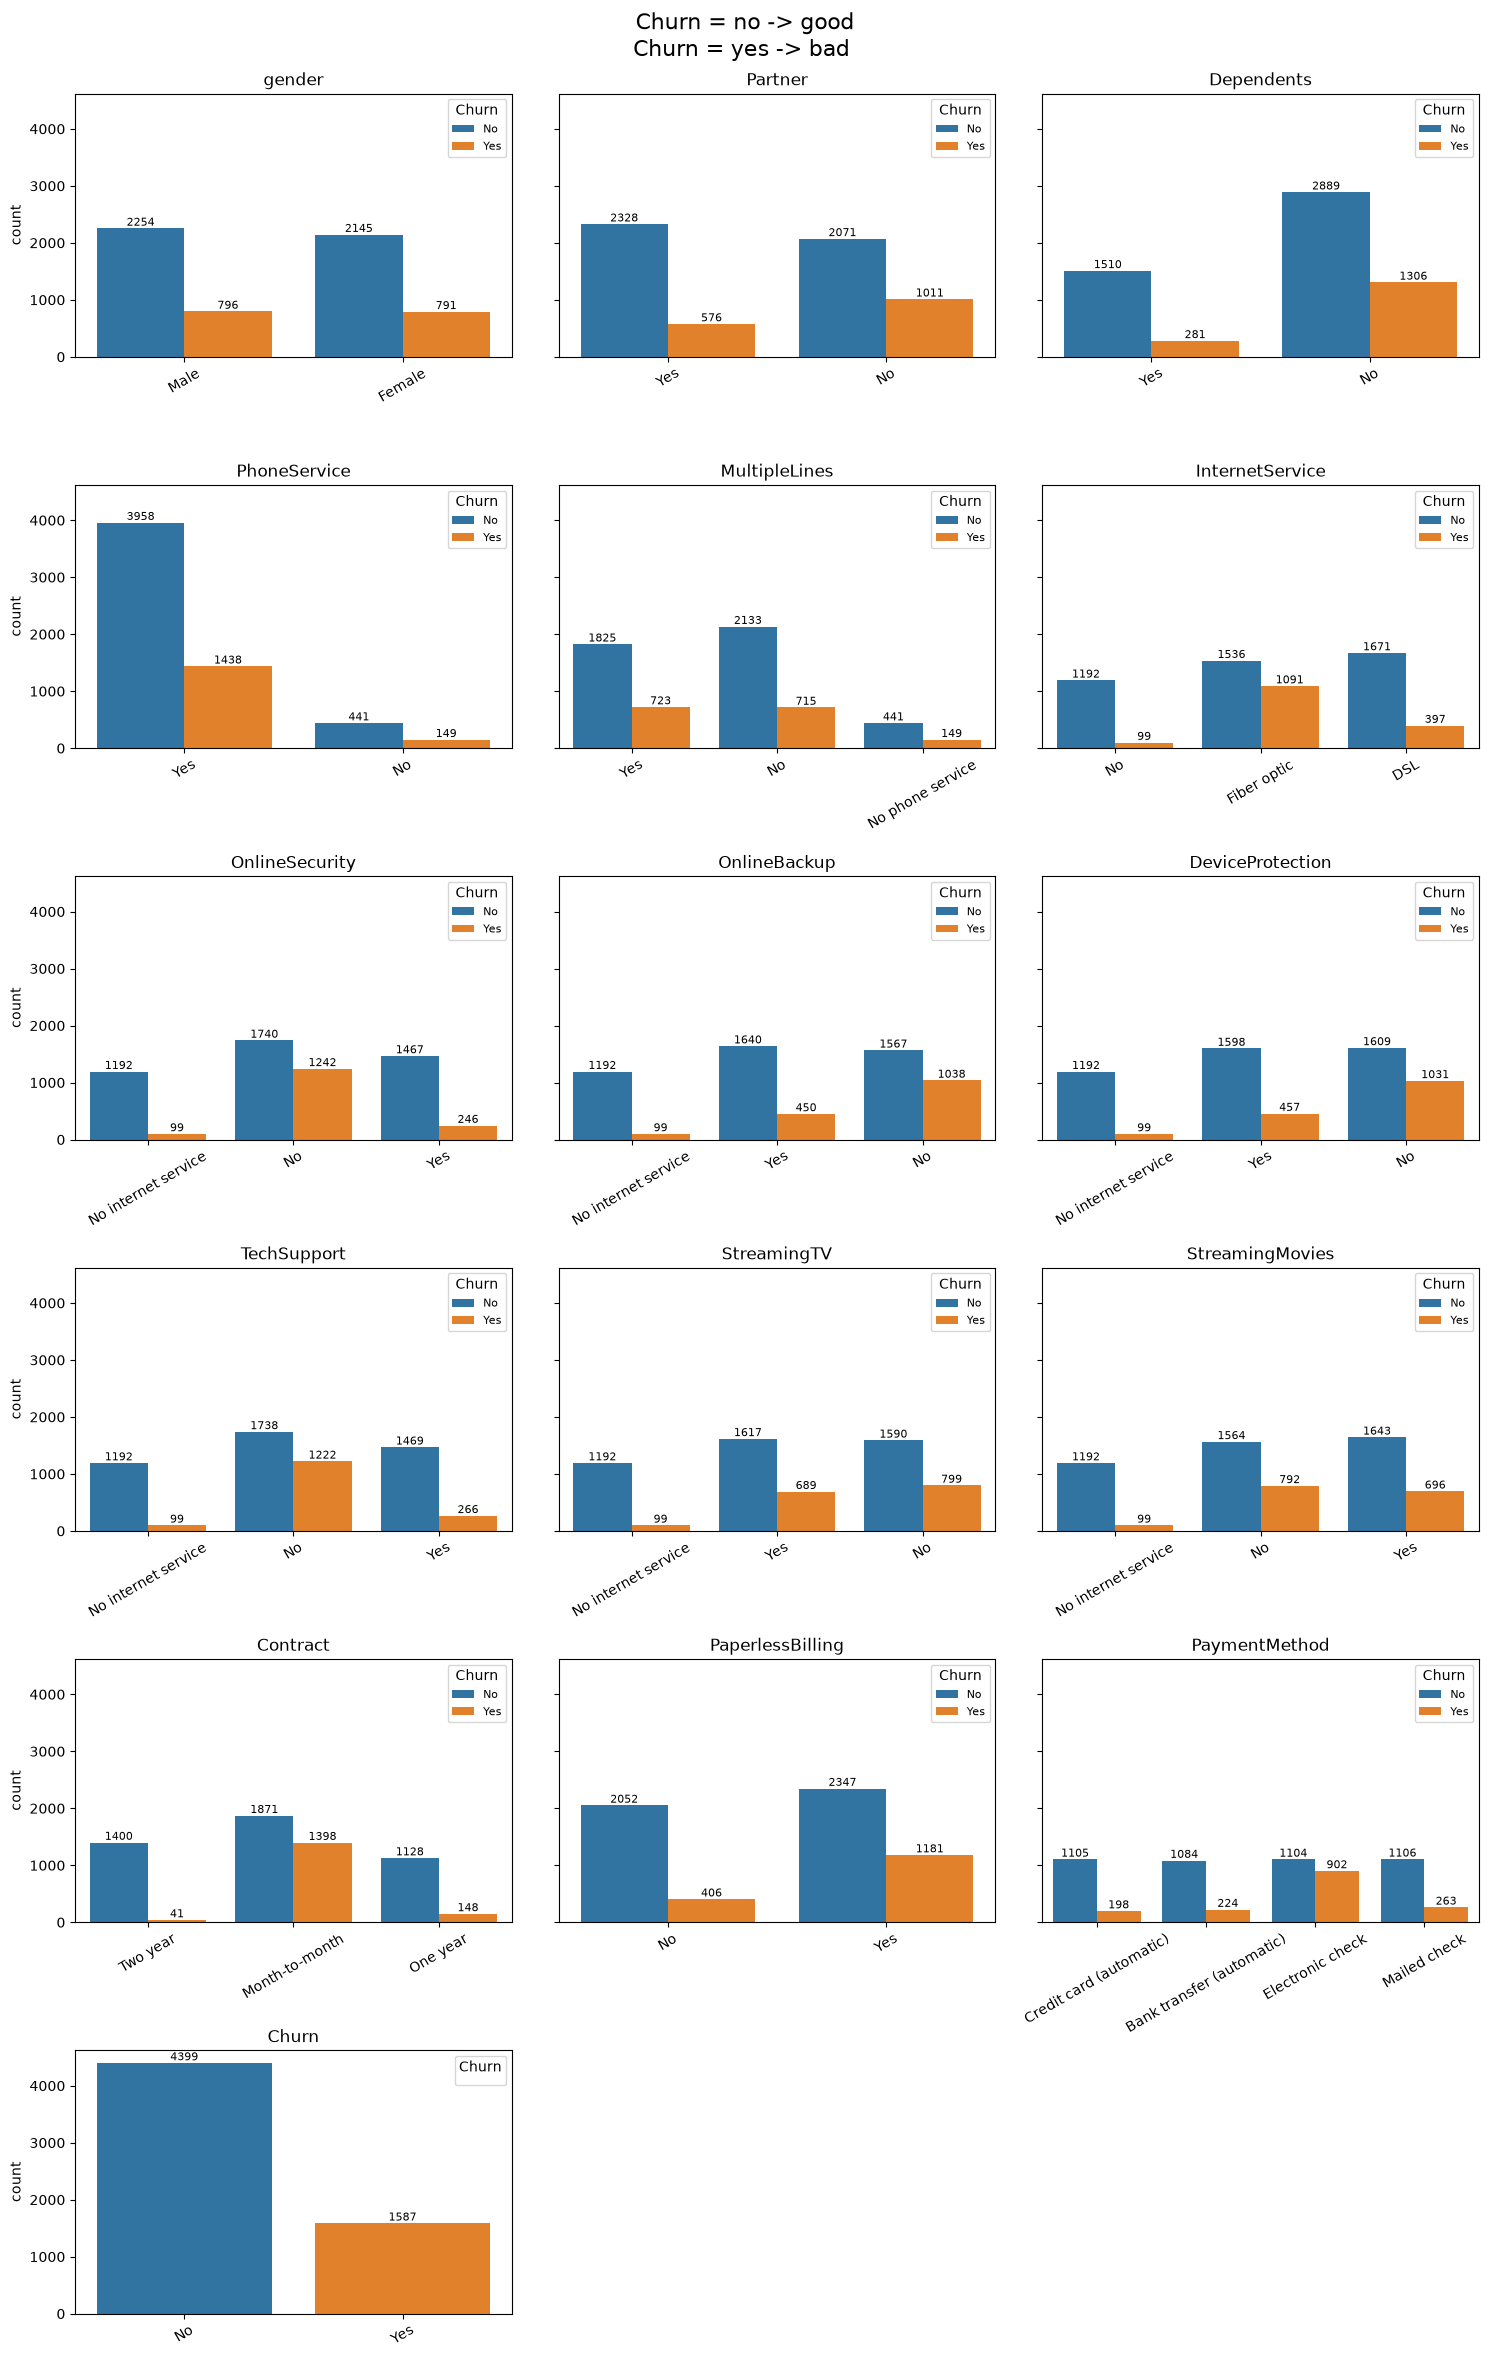

In [40]:
import math
ncols = 3
nrows = math.ceil(len(cat_features) / ncols)  # cat_features = your list of categorical columns
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True, squeeze=False)

for ax, c in zip(axes.flat, cat_features):
    sns.countplot(data=df, x=c, hue="Churn", hue_order=["No", "Yes"], ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=8)          # exact count on each bar
    ax.set_title(c)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Churn", fontsize=8)

for ax in axes.flat[len(cat_features):]:        # hide unused panels
    ax.axis("off")
fig.suptitle("""Churn = no -> good
Churn = yes -> bad 
""", fontsize=16) #(title={"text":"Sepal length vs sepal width", 'x':0.5, 'xanchor':'center'}, font=dict(size=20))
plt.tight_layout()
plt.show()

In [321]:
cat_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [324]:
cat_features2 = cat_features + ['SeniorCitizen'] 
cat_features2

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [325]:
for col in cat_features2:
    ratios = pd.crosstab(df[col], df['Churn'], normalize='index').round(3)
    counts = df[col].value_counts()
    summary = ratios.assign(n=counts)
    print(f"\n{col}")
    display(summary)


gender


Churn,No,Yes,n
gender,,,
Female,0.731,0.269,2936
Male,0.739,0.261,3050



Partner


Churn,No,Yes,n
Partner,,,
No,0.672,0.328,3082
Yes,0.802,0.198,2904



Dependents


...

Churn,No,Yes,n
PaymentMethod,,,
Bank transfer (automatic),0.829,0.171,1308
Credit card (automatic),0.848,0.152,1303
Electronic check,0.550,0.450,2006
Mailed check,0.808,0.192,1369



Churn


Churn,No,Yes,n
Churn,,,
No,1.0,0.0,4399
Yes,0.0,1.0,1587



SeniorCitizen


Churn,No,Yes,n
SeniorCitizen,,,
0,0.764,0.236,5020
1,0.584,0.416,966


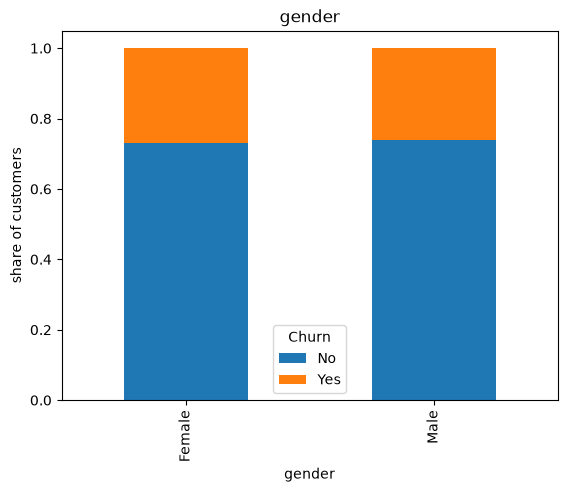

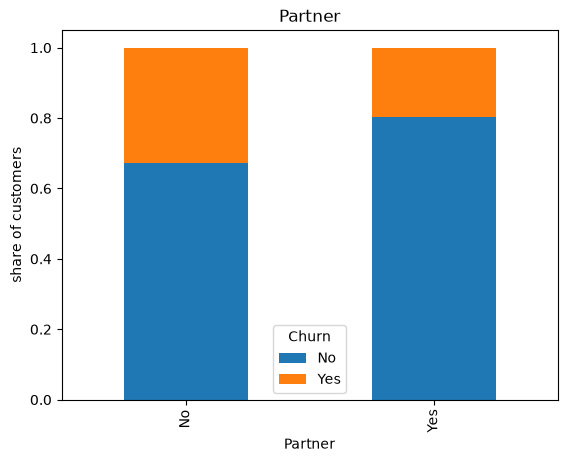

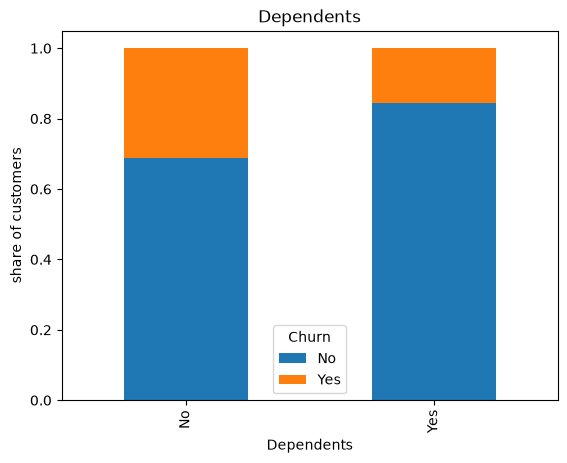

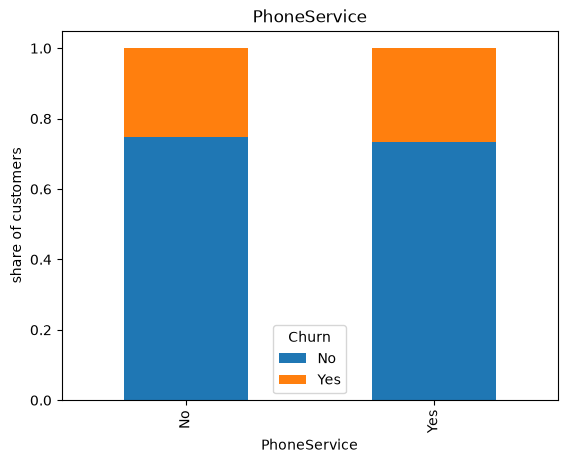

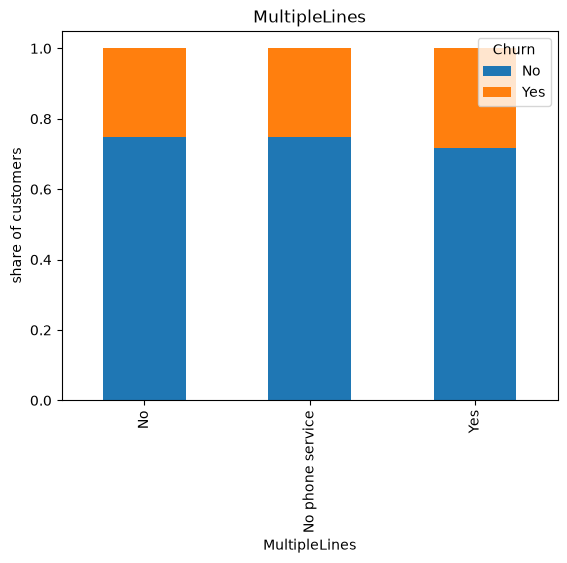

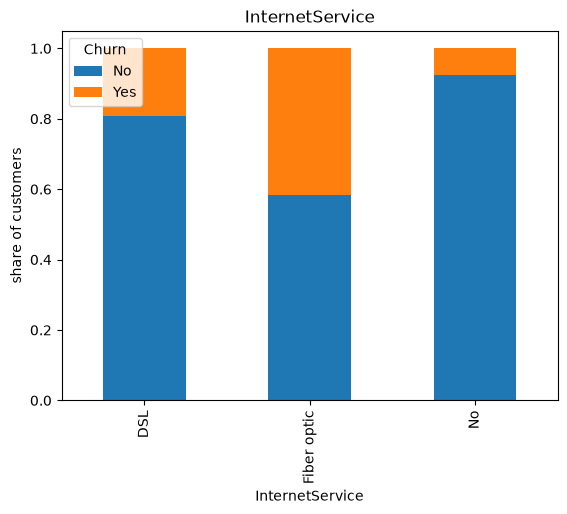

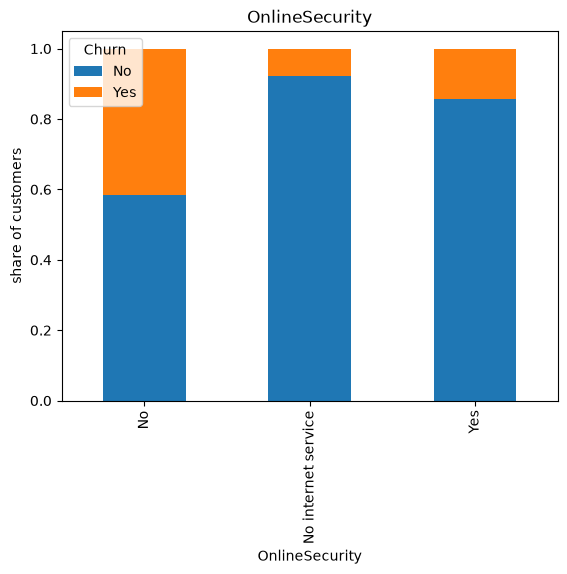

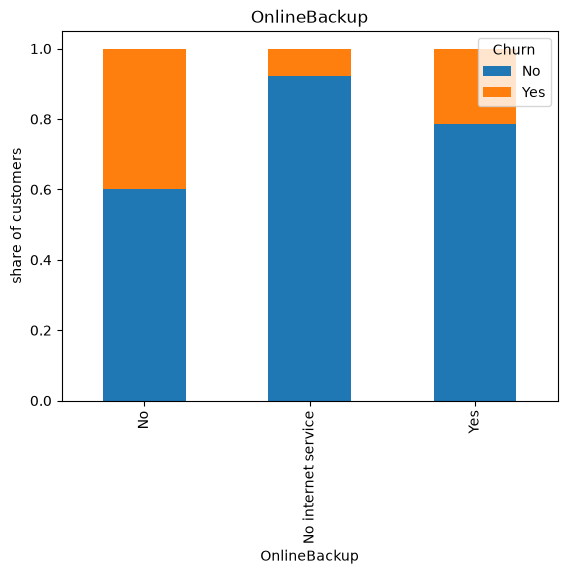

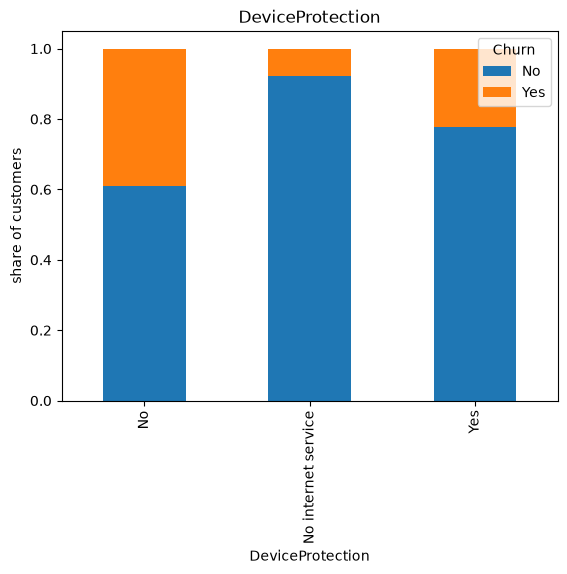

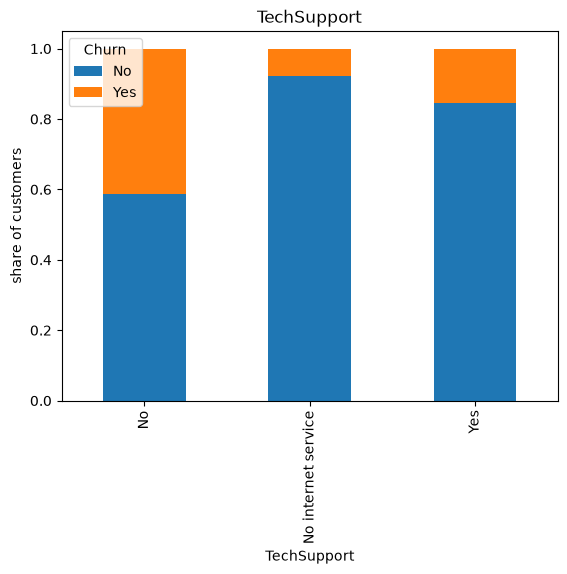

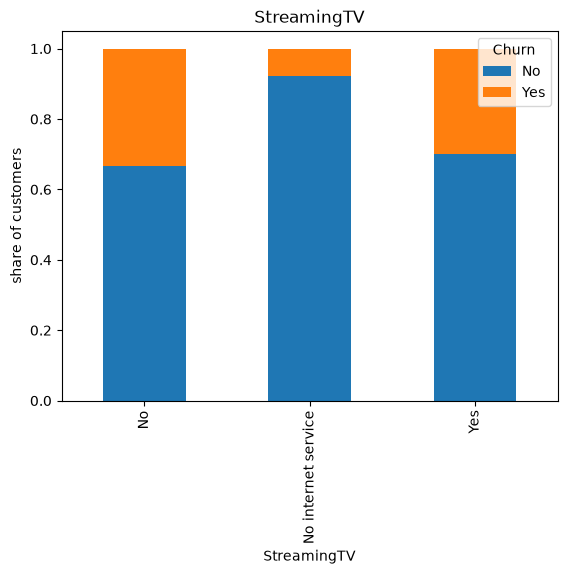

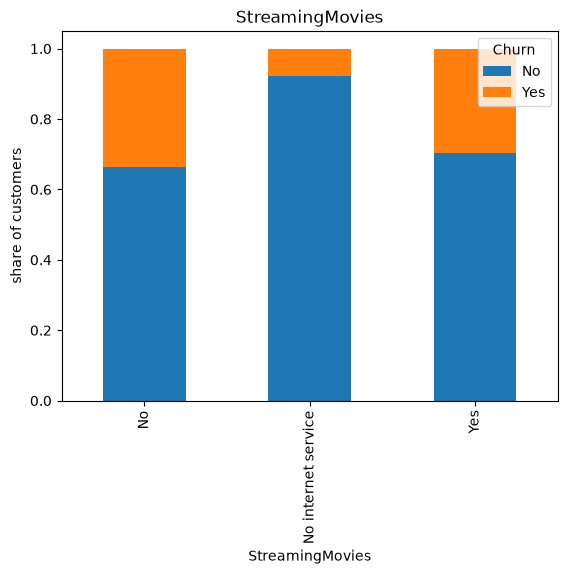

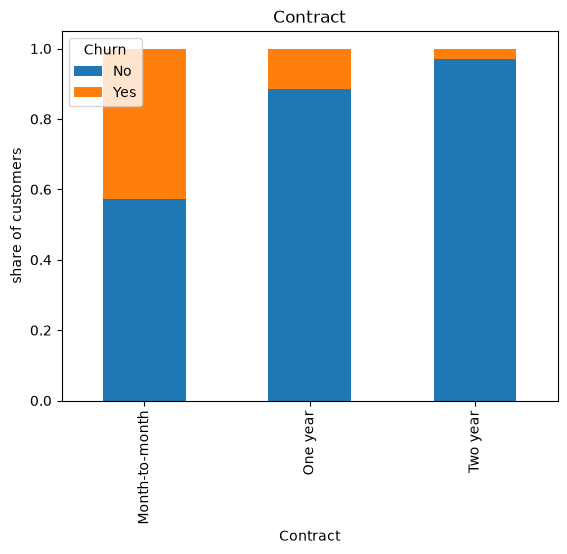

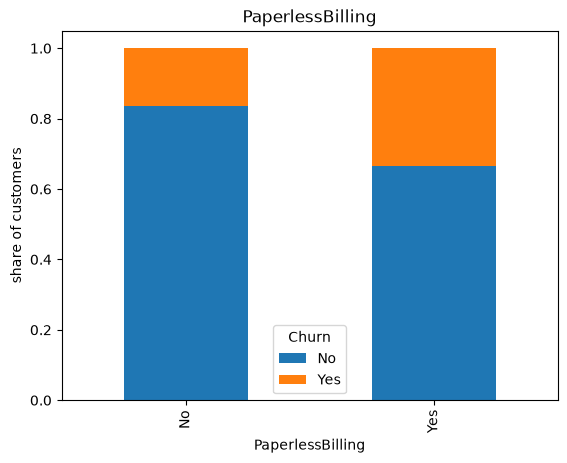

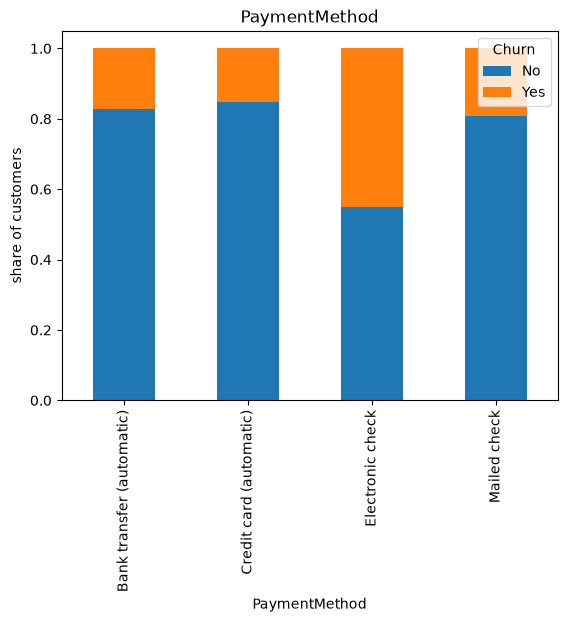

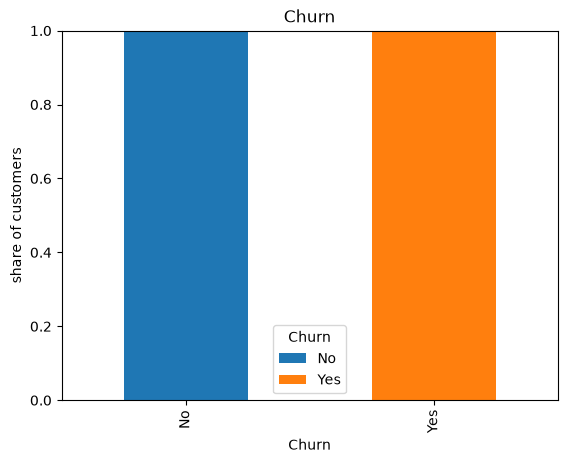

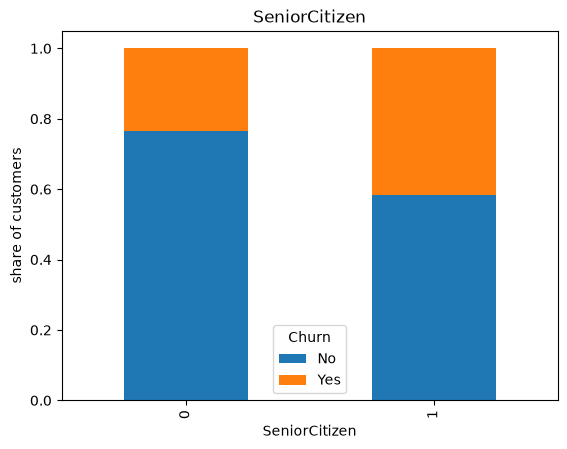

In [326]:
import matplotlib.pyplot as plt

for col in cat_features2:
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(kind='bar', stacked=True)
    plt.ylabel('share of customers')
    plt.title(col)
    plt.show()

In [798]:
df['contract2'] = df['Contract'].replace({'One year': 'Yearly', 'Two year': 'Yearly'})
df = df.drop(columns='Contract')
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,contract2
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,Credit card (automatic),24.10,1734.65,No,Yearly
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Yes,Credit card (automatic),88.15,3973.20,No,Month-to-month
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Yes,Bank transfer (automatic),74.95,2869.85,Yes,Month-to-month
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Yes,Electronic check,55.90,238.50,No,Month-to-month
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,No,Electronic check,53.45,119.50,No,Month-to-month
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5981,Male,0,Yes,No,1,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Yes,Electronic check,95.00,95.00,Yes,Month-to-month
5982,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Credit card (automatic),91.10,2198.30,No,Yearly
5983,Male,0,Yes,Yes,12,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Yes,Electronic check,21.15,306.05,No,Month-to-month
5984,Male,1,No,No,12,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Yes,Electronic check,99.45,1200.15,Yes,Month-to-month


In [430]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2006
Mailed check                 1369
Bank transfer (automatic)    1308
Credit card (automatic)      1303
Name: count, dtype: int64

In [524]:
df["PaymentMethod2"] = df["PaymentMethod"].replace({"Mailed check":"Necessary","Bank transfer (automatic)":"Necessary","Credit card (automatic)" :"Necessary" })
df = df.drop(columns='PaymentMethod')


In [433]:
df["PaymentMethod2"].value_counts()

PaymentMethod2
Necessary           3980
Electronic check    2006
Name: count, dtype: int64

## Always do clustering after data splitting.

## 4. Splitting the data
With limited amount of data (<1000) it is usually better to do the split with smaller split size (10%).

## Based on the analyzis above I am drpping gender, and multiple lines to see if it makes a difference, as those columns did not really bare any information. 

In [835]:
X = df.drop(columns=['Churn'])
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) #Stratify makes sure that the split of the data will have the same proportion of the "y" variable as the original dataset. Basically the next line of code for the proportion checking becomes unnecessary. "y" referes to the column and not to "yes"!!
X_train.shape, X_test.shape

((4190, 19), (1796, 19))

In [724]:
print(y_train.value_counts(normalize=True), y_test.value_counts(normalize=True))

Churn
No     0.734962
Yes    0.265038
Name: proportion, dtype: float64 Churn
No     0.734558
Yes    0.265442
Name: proportion, dtype: float64


# 5. Training 



## Separate categorical and numeric columns

We will need to treat these features separately just like before

In [800]:
categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()


## Define Categorical and Numerical Transformer Pipeline

Tranformation of the categorical features:

- Constant imputer (SimpleImputer) to fill missing values
- One-hot encoder to get dummy variables

Tranformation of the categorical features:

- Standard Scaler to scale the numeric features
- K-nearest neighbor imputer to fill missing values

Processor: tranform all the features in sequence

- Numeric Transfomer defined earlier
- Categorical Transfomer defined earlier

In [801]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("scaler", StandardScaler().set_output(transform="pandas")),
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) #This is in here to fill in NaN-s because some model would crush on missing vales. 
                                      ])

preprocessor = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

# Splitting by subgroups

In [388]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.20,No
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.50,No
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.50,No


In [389]:
df_int = df[df["InternetService"] != "No"]
df_int["InternetService"].value_counts()

InternetService
Fiber optic    2627
DSL            2068
Name: count, dtype: int64

In [390]:
df_int.shape

(4695, 20)

In [391]:
df_no_int = df[df["InternetService"] == "No"]
df_no_int.shape

(1291, 20)

In [392]:
for col in df_no_int.columns:
    print(f"\n{col}:")
    print(df_no_int[col].nunique(dropna=False))


gender:
2

SeniorCitizen:
2

Partner:
2

Dependents:
2

tenure:
73

PhoneService:
1

MultipleLines:
2

InternetService:
1

OnlineSecurity:
1

OnlineBackup:
1

DeviceProtection:
1

TechSupport:
1

StreamingTV:
1

StreamingMovies:
1

Contract:
3

PaperlessBilling:
2

PaymentMethod:
4

MonthlyCharges:
120

TotalCharges:
1189

Churn:
2


In [393]:
const_cols = []
for col in df_no_int.columns:
    if df_no_int[col].nunique(dropna=False) == 1:
        const_cols.append(col)

df_no_int2 = df_no_int.drop(columns=const_cols)
df_no_int2.shape

(1291, 12)

# Run it after the regular data is done!

In [609]:
X = df_int.drop(columns=['Churn'])
y = df_int['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #Stratify makes sure that the split of the data will have the same proportion of the "y" variable as the original dataset. Basically the next line of code for the proportion checking becomes unnecessary. "y" referes to the column and not to "yes"!!

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()


## Logistic Regression Modeling Pipeline

Chains the following steps:

- Preprocessing pipeline steps defined earlier (categorical to numerical encoding, scaling, filling NaNs)
- Logistic Regression model 

## Train and Evaluate Logistic Regression ML Pipeline



In [836]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline(steps=[
                              ("pre_process", preprocessor),
                              ("model", LogisticRegression(random_state=42, solver='liblinear'))
                              ])


pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

class_labels = pipeline_lr.named_steps['model'].classes_ #I do not know what is the purpose of these class lables. 

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)


              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1320
         Yes       0.65      0.51      0.57       476

    accuracy                           0.80      1796
   macro avg       0.74      0.70      0.72      1796
weighted avg       0.79      0.80      0.79      1796



,No,Yes
No,1187,133
Yes,233,243


In [837]:
scores = {}
scores['log_reg'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788}

## Train and Evaluate K Nearest Neighbors (KNN) ML Pipeline


In [838]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
pipeline_knn = Pipeline([("pre_process", preprocessor),
                            ("model", KNeighborsClassifier(n_neighbors=11))])

pipeline_knn.fit(X_train, y_train)
y_pred = pipeline_knn.predict(X_test)

class_labels = pipeline_knn.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.84      0.86      0.85      1320
         Yes       0.58      0.54      0.56       476

    accuracy                           0.77      1796
   macro avg       0.71      0.70      0.70      1796
weighted avg       0.77      0.77      0.77      1796



,No,Yes
No,1133,187
Yes,219,257


In [839]:
scores['knn'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788, 'knn': 0.771}

## Train and Evaluate SVM ML Pipeline


In [840]:
from sklearn.svm import LinearSVC
pipeline_svc = Pipeline([("pre_process", preprocessor),
                         ("model", LinearSVC(random_state=42, max_iter=10000))])


pipeline_svc.fit(X_train, y_train)
y_pred = pipeline_svc.predict(X_test)

class_labels = pipeline_svc.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1320
         Yes       0.66      0.50      0.57       476

    accuracy                           0.80      1796
   macro avg       0.75      0.70      0.72      1796
weighted avg       0.79      0.80      0.79      1796



,No,Yes
No,1196,124
Yes,237,239


In [841]:
scores['svm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788, 'knn': 0.771, 'svm': 0.79}

## Train and Evaluate Naive Bayes ML Pipeline
This model does not need scaling.
MultinomialNB / ComplementNB would crash after standardization, given the negative values.

Which distribution to use:
- BernoulliNB assumes binary (0/1) features. By default it binarises every feature at binarize=0.0, so with continuous, all-positive data nearly everything becomes 1 and the model loses most of the information.
- GaussianNB is the one for continuous numeric features. 
- MultinomialNB is for counts, like word frequencies.

In [842]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) # no standard scaling for numeric data
                                      ]) #see there is no scaler here

preprocessor_new = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

In [843]:
from sklearn.naive_bayes import BernoulliNB

pipeline_nb = Pipeline([("pre_process", preprocessor_new),
                         ("model", BernoulliNB())
                         ])

pipeline_nb.fit(X_train, y_train)
y_pred = pipeline_nb.predict(X_test)

class_labels = pipeline_nb.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.90      0.69      0.78      1320
         Yes       0.48      0.78      0.59       476

    accuracy                           0.72      1796
   macro avg       0.69      0.74      0.69      1796
weighted avg       0.79      0.72      0.73      1796



,No,Yes
No,916,404
Yes,106,370


In [844]:
scores['nb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788, 'knn': 0.771, 'svm': 0.79, 'nb': 0.732}

## Tree-based models don't require data to be scaled - hence the new processer is used down the line.

Tree based models are non-linear and are not distance based models. Hence we will create a new transformation pipeline without scaling

## Train and Evaluate Decision Tree ML Pipeline


In [845]:
from sklearn.tree import DecisionTreeClassifier
pipeline_dtree = Pipeline([("pre_process", preprocessor_new),
                         ("model", DecisionTreeClassifier(random_state=42))])


pipeline_dtree.fit(X_train, y_train)
y_pred = pipeline_dtree.predict(X_test)

class_labels = pipeline_dtree.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.81      0.81      0.81      1320
         Yes       0.47      0.47      0.47       476

    accuracy                           0.72      1796
   macro avg       0.64      0.64      0.64      1796
weighted avg       0.72      0.72      0.72      1796



,No,Yes
No,1063,257
Yes,252,224


In [846]:
scores['dtree'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788, 'knn': 0.771, 'svm': 0.79, 'nb': 0.732, 'dtree': 0.717}

## Train and Evaluate Random Forest ML Pipeline


In [847]:
from sklearn.ensemble import RandomForestClassifier
pipeline_rf = Pipeline([("pre_process", preprocessor_new),
                         ("model", RandomForestClassifier(random_state=42))])

pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

class_labels = pipeline_rf.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1320
         Yes       0.63      0.46      0.53       476

    accuracy                           0.79      1796
   macro avg       0.73      0.68      0.70      1796
weighted avg       0.77      0.79      0.77      1796



,No,Yes
No,1190,130
Yes,256,220


In [848]:
scores['rf'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788,
 'knn': 0.771,
 'svm': 0.79,
 'nb': 0.732,
 'dtree': 0.717,
 'rf': 0.774}

## Train and Evaluate AdaBoost ML Pipeline


In [849]:
from sklearn.ensemble import AdaBoostClassifier

pipeline_ada_boost = Pipeline([("pre_process", preprocessor_new),
                         ("model", AdaBoostClassifier(random_state=42))])


pipeline_ada_boost.fit(X_train, y_train)
y_pred = pipeline_ada_boost.predict(X_test)

class_labels = pipeline_ada_boost.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1320
         Yes       0.63      0.51      0.56       476

    accuracy                           0.79      1796
   macro avg       0.73      0.70      0.71      1796
weighted avg       0.78      0.79      0.78      1796



,No,Yes
No,1178,142
Yes,233,243


In [850]:
scores['ada_boost'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788,
 'knn': 0.771,
 'svm': 0.79,
 'nb': 0.732,
 'dtree': 0.717,
 'rf': 0.774,
 'ada_boost': 0.784}

## Train and Evaluate Gradient Boosting ML Pipeline


In [851]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gbm = Pipeline([("pre_process", preprocessor_new),
                         ("model", GradientBoostingClassifier(random_state=42))])


pipeline_gbm.fit(X_train, y_train)
y_pred = pipeline_gbm.predict(X_test)

class_labels = pipeline_gbm.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1320
         Yes       0.65      0.51      0.57       476

    accuracy                           0.80      1796
   macro avg       0.74      0.71      0.72      1796
weighted avg       0.79      0.80      0.79      1796



,No,Yes
No,1189,131
Yes,232,244


In [852]:
scores['gbm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788,
 'knn': 0.771,
 'svm': 0.79,
 'nb': 0.732,
 'dtree': 0.717,
 'rf': 0.774,
 'ada_boost': 0.784,
 'gbm': 0.79}

## Train and Evaluate Extreme Gradient Boosting (XGBoost) ML Pipeline


In [853]:
from xgboost import XGBClassifier
pipeline_xgb = Pipeline([("pre_process", preprocessor_new),
                         ("model", XGBClassifier(random_state=42))])



In [854]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# transform y labels into 0 and 1 as latest xgboost version doesn't support string labels
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [855]:
pipeline_xgb.fit(X_train, y_train_le)
y_pred_le = pipeline_xgb.predict(X_test)

In [856]:
y_pred = le.inverse_transform(y_pred_le)

In [857]:
class_labels = le.classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.87      0.85      1320
         Yes       0.58      0.49      0.53       476

    accuracy                           0.77      1796
   macro avg       0.70      0.68      0.69      1796
weighted avg       0.76      0.77      0.76      1796



,No,Yes
No,1152,168
Yes,244,232


In [858]:
scores['xgb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.788,
 'knn': 0.771,
 'svm': 0.79,
 'nb': 0.732,
 'dtree': 0.717,
 'rf': 0.774,
 'ada_boost': 0.784,
 'gbm': 0.79,
 'xgb': 0.764}

## Compare model performances

In [859]:
result = pd.DataFrame({
    "Model" : scores.keys(),
    'F1-Score': scores.values()
})

result

,Model,F1-Score
0,log_reg,0.788
1,knn,0.771
2,svm,0.790
3,nb,0.732
4,dtree,0.717
5,rf,0.774
6,ada_boost,0.784
7,gbm,0.790
8,xgb,0.764


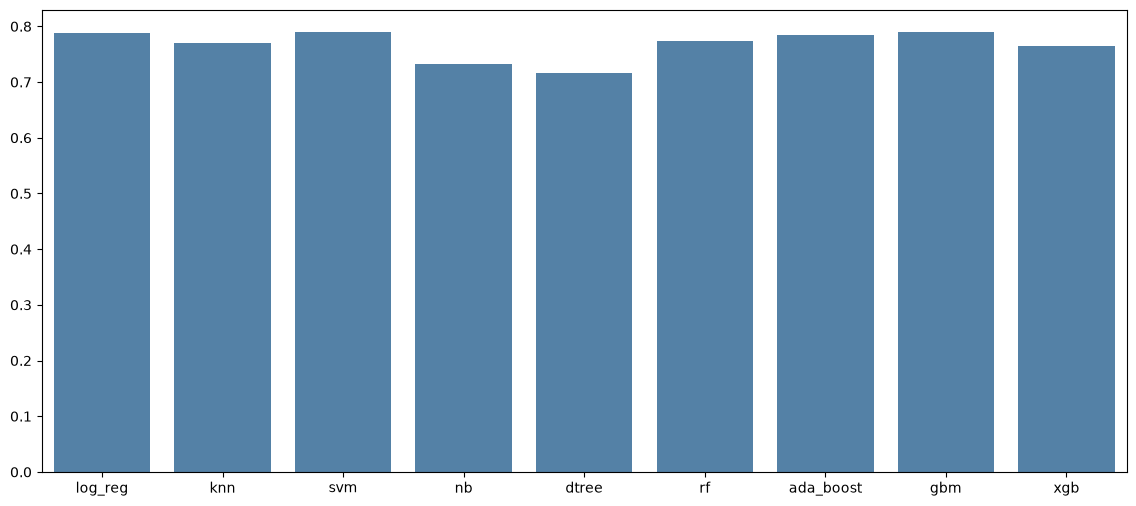

In [860]:
plt.figure(figsize=(14, 6))
sns.barplot(x=list(scores.keys()),
            y=list(scores.values()), color="Steelblue");

## Feature Importance

Trees based models like RandomForest, XGBoost, etc.  provide us feature importance based on the training.

In [861]:
xgb_model = pipeline_xgb['model']
feature_names = pipeline_xgb['pre_process'].get_feature_names_out()
feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__PhoneService_No',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__

In [862]:
xgb_model.feature_importances_

array([0.01441859, 0.01759403, 0.01372601, 0.01238642, 0.01029468,
       0.        , 0.0121319 , 0.        , 0.01094577, 0.        ,
       0.01304276, 0.        , 0.01351681, 0.        , 0.01481668,
       0.03672598, 0.08132974, 0.00650632, 0.04859733, 0.        ,
       0.01339195, 0.01821132, 0.        , 0.00743947, 0.00941923,
       0.        , 0.01587967, 0.01819268, 0.        , 0.00794164,
       0.01259193, 0.        , 0.01047593, 0.01467517, 0.        ,
       0.02000582, 0.0167361 , 0.        , 0.01117101, 0.01256851,
       0.0231208 , 0.0097127 , 0.47243312, 0.        ], dtype=float32)

In [863]:
xgb_importances = pd.DataFrame(
    {"feature": feature_names, "importance": np.round(xgb_model.feature_importances_, 3)}
)
xgb_importances = xgb_importances.sort_values("importance", ascending=False).set_index(
    "feature"
)
xgb_importances.head(20)

,importance
feature,
cat__contract2_Month-to-month,0.472
cat__InternetService_Fiber optic,0.081
cat__OnlineSecurity_No,0.049
cat__InternetService_DSL,0.037
cat__PaymentMethod_Electronic check,0.023
cat__StreamingMovies_Yes,0.020
cat__OnlineBackup_No,0.018
cat__TechSupport_No,0.018
num__tenure,0.018


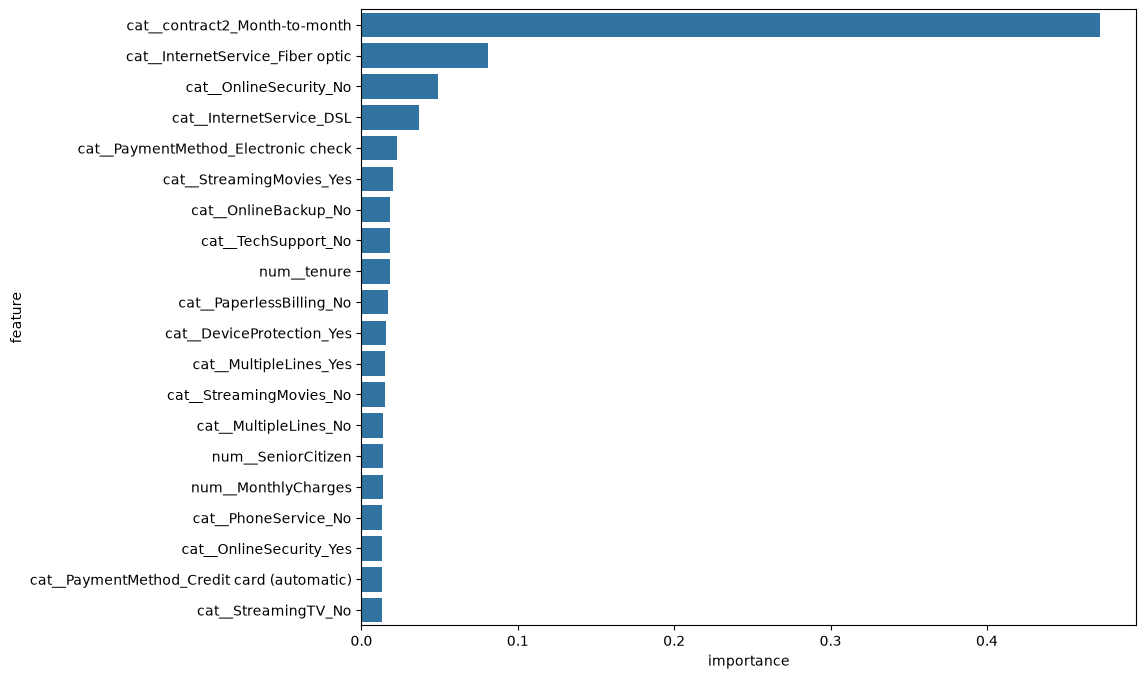

In [864]:
plt.figure(figsize=(10, 8))
sns.barplot(y=xgb_importances.head(20).index,
            x=xgb_importances.head(20).importance);

## Cross-Validation Evaluation and Model Comparison (Optional)

Standard process followed in the industry to compare multiple ML models

In [865]:
from sklearn.model_selection import cross_val_score

#### Cross-Validating based on Average F1 score

In [866]:
cvs = 3
scores_cv = {}
scores_cv['log_reg'] = cross_val_score(pipeline_lr, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['knn'] = cross_val_score(pipeline_knn, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['nb'] = cross_val_score(pipeline_nb, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['svm'] = cross_val_score(pipeline_svc, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['dtree'] = cross_val_score(pipeline_dtree, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['rf'] = cross_val_score(pipeline_rf, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['ada_boost'] = cross_val_score(pipeline_ada_boost, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['gbm'] = cross_val_score(pipeline_gbm, X_train, y_train, cv=cvs, scoring='f1_weighted')
# here labels need to be used as 0 and 1 which are label encoded
scores_cv['xgb'] = cross_val_score(pipeline_xgb, X_train, y_train_le, cv=cvs, scoring='f1_weighted')

In [867]:
result = pd.DataFrame({
    "Model" : scores_cv.keys(),
    'F1-Score': [round(np.mean(scores), 3) for scores in scores_cv.values()]
})

result.sort_values("F1-Score", ascending=False)

,Model,F1-Score
0,log_reg,0.799
3,svm,0.795
7,gbm,0.792
6,ada_boost,0.791
8,xgb,0.776
5,rf,0.775
1,knn,0.774
2,nb,0.736
4,dtree,0.722


In [868]:
from flaml import AutoML-ó

automl = AutoML()

automl_settings = {
    "time_budget": 30, # 10 mins to try and select the best model
    "metric": 'macro_f1', #if it is only f1, then it expect a binary classification. Macro averages it out....
    "task": 'classification',
    "log_file_name": 'mylog.log',
    #"estimator_list": ["xgboost", "catboost", "rf", "extra_tree"], #needs to check if I need this row or not
    "seed": 42
}
automl.fit(X_train=X_train, y_train=y_train_le, # ensemble=True, if we add this, then it would combine the best models into a final model. It takes more computing, and makes the model less explainable. 
           **automl_settings)

SyntaxError: invalid syntax (290993890.py, line 1)

In [ ]:
automl.best_estimator

'xgb_limitdepth'

In [ ]:
automl.best_config

{'n_estimators': 654,
 'max_depth': 2,
 'min_child_weight': np.float64(0.4647948203942593),
 'learning_rate': np.float64(0.12722890798060188),
 'subsample': np.float64(0.8442404358792689),
 'colsample_bylevel': np.float64(0.8582934378476018),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0202911914724552),
 'reg_lambda': np.float64(241.49725858670791)}

In [ ]:
automl.model.get_params()

{'n_estimators': 654,
 'max_depth': 2,
 'min_child_weight': np.float64(0.4647948203942593),
 'learning_rate': np.float64(0.12722890798060188),
 'subsample': np.float64(0.8442404358792689),
 'colsample_bylevel': np.float64(0.8582934378476018),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0202911914724552),
 'reg_lambda': np.float64(241.49725858670791),
 'n_jobs': -1,
 'verbosity': 0,
 'random_state': 10242048,
 'task': <flaml.automl.task.generic_task.GenericTask at 0x1be094c0d50>,
 '_estimator_type': 'classifier'}

In [ ]:
y_pred = automl.predict(X_test)

In [ ]:
print(classification_report(y_test_le, y_pred))
f1_score(y_test_le, y_pred, average='weighted')

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       880
           1       0.65      0.51      0.57       318

    accuracy                           0.80      1198
   macro avg       0.74      0.71      0.72      1198
weighted avg       0.79      0.80      0.79      1198



0.7886460250277839

# Result without combining any of the two (payment or contract) but wit 30% split
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.798</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.795</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.794</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.776</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.775</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.772</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.734</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.727</td>
    </tr>
  </tbody>
</table>
</div>

# Result with 30% split, and only combined payment method
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.798</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.773</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.772</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.770</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.732</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.727</td>
    </tr>
  </tbody>
</table>
</div>

# Result with 30% split, and only combined contracts

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.799</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.795</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.792</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.791</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.776</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.775</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.774</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.736</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.722</td>
    </tr>
  </tbody>
</table>
</div>

# When grouping payment methods and contract type
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.797</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.790</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.783</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.779</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.776</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.739</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.738</td>
    </tr>
  </tbody>
</table>
</div>

# Results

## Results of the original run, no group sep:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.798</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.794</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.784</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.778</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.777</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.742</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.737</td>
    </tr>
  </tbody>
</table>
</div>

model: xgb_limitdepth

precision    recall  f1-score   support

           0       0.84      0.90      0.87       880
           1       0.65      0.51      0.57       318

    accuracy                           0.80      1198
   macro avg       0.74      0.71      0.72      1198
weighted avg       0.79      0.80      0.79      1198

{'n_estimators': 654,
 'max_depth': 2,
 'min_child_weight': np.float64(0.4647948203942593),
 'learning_rate': np.float64(0.12722890798060188),
 'subsample': np.float64(0.8442404358792689),
 'colsample_bylevel': np.float64(0.8582934378476018),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0202911914724552),
 'reg_lambda': np.float64(241.49725858670791)}

## Predictions of the internet group

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.761</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.758</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.757</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.749</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.748</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.735</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.733</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.720</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.692</td>
    </tr>
  </tbody>
</table>
</div>

after 10 min Auto ML

precision    recall  f1-score   support

           0       0.80      0.86      0.83       641
           1       0.64      0.55      0.59       298

    accuracy                           0.76       939
   macro avg       0.72      0.70      0.71       939
weighted avg       0.75      0.76      0.75       939


{'n_estimators': 19,
 'max_depth': 3,
 'min_child_weight': np.float64(0.16278088111539776),
 'learning_rate': 1.0,
 'subsample': np.float64(0.6949725916375937),
 'colsample_bylevel': np.float64(0.914347466686421),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.017033884749263227),
 'reg_lambda': np.float64(379.2942506687784)}

## Predictions of the no internet group  - very low sample rate
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.898</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.891</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.888</td>
    </tr>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.887</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.887</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.886</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.883</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.873</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.860</td>
    </tr>
  </tbody>
</table>
</div>

10 min autoML 
{'penalty': np.str_('elasticnet'),
 'alpha': np.float64(1.0907499681742529e-06),
 'l1_ratio': np.float64(0.08626681209818353),
 'epsilon': np.float64(0.04724875710415196),
 'learning_rate': np.str_('optimal'),
 'eta0': np.float64(0.0035367964690083587),
 'power_t': np.float64(0.5177894669051555),
 'average': False,
 'loss': 'log_loss'}

 model SGD 
 precision    recall  f1-score   support

           0       0.97      0.88      0.92       239
           1       0.32      0.65      0.43        20

    accuracy                           0.86       259
   macro avg       0.64      0.77      0.67       259
weighted avg       0.92      0.86      0.89       259